In [1]:
import numpy as np
from scipy import sparse
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

X_train = sparse.load_npz("../data/processed/X_train.npz")
X_test = sparse.load_npz("../data/processed/X_test.npz")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (7519, 438) | X_test: (2025, 438)


In [2]:
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [3]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}  (en moyenne, le modèle se trompe de {mae:.3f} sur le score)")
print(f"R²  : {r2:.4f}")

MSE : 0.0247
MAE : 0.1227  (en moyenne, le modèle se trompe de 0.123 sur le score)
R²  : 0.2067


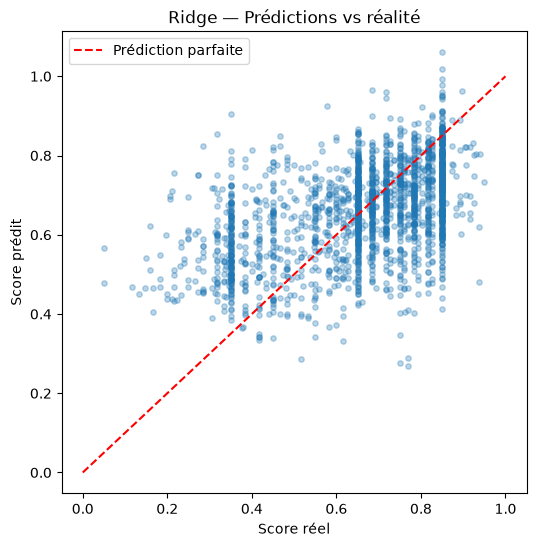

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=15)
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Prédiction parfaite")
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Ridge — Prédictions vs réalité")
plt.legend()
plt.show()

In [5]:
import joblib
import pandas as pd

tfidf = joblib.load("../data/processed/tfidf_vectorizer.pkl")
ohe = joblib.load("../data/processed/job_position_encoder.pkl")

numeric_cols = [
    "skills_overlap", "experience_years_min",
    "has_career_objective", "has_certifications", "has_languages",
    "has_extra_curricular", "has_skills_required",
    "has_experience_requirement", "has_age_requirement",
]

In [6]:
feature_names = (
    list(tfidf.get_feature_names_out())      # resume_tfidf
    + list(tfidf.get_feature_names_out())     # job_tfidf (même vectorizer, réutilisé)
    + ["text_similarity"]
    + numeric_cols
    + list(ohe.get_feature_names_out())
)

print(f"Nombre de noms générés : {len(feature_names)} | Nombre de coefficients : {len(model.coef_)}")

coefs = pd.Series(model.coef_, index=feature_names[:len(model.coef_)])

print("Top 10 features qui augmentent le score prédit :")
print(coefs.sort_values(ascending=False).head(10))

print("\nTop 10 features qui diminuent le score prédit :")
print(coefs.sort_values().head(10))

Nombre de noms générés : 438 | Nombre de coefficients : 438
Top 10 features qui augmentent le score prédit :
text_similarity    0.389315
performance        0.355383
etl                0.269910
mba                0.241260
database           0.218890
degree             0.210629
solving            0.207072
ios                0.203811
masters            0.197984
inventory          0.197969
dtype: float64

Top 10 features qui diminuent le score prédit :
cisco                    -0.374133
safety                   -0.232772
civil engineering        -0.230216
mechanical engineering   -0.221017
installation             -0.217557
sc                       -0.215106
developer                -0.195478
backup                   -0.193809
monitoring               -0.186813
systems                  -0.185052
dtype: float64
